### Synthetic EEG evaluation tutorial

#### Import packages

In [2]:
import pickle
from preprocessing import *
from amplitude_fidelity import *
from frequency_fidelity import *
from time_frequency_fidelity import *
from complexity_fidelity import *
from time_fidelity import *
from diversity2 import *
from privacy import *
import evaluation_score
from itertools import product

Data processed.


In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3), dpi=100)
import seaborn as sns

sns.set_theme(style='whitegrid', rc={
    'figure.figsize': (6, 3),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

<Figure size 600x300 with 0 Axes>

#### A. Preprocessing

1. Load data
2. Downsampling
3. Normalization

#### A1. Load data

In [8]:
real_data = load_pickle("data/5_real_examples.pkl")
synthetic_data = load_pickle("data/5_synthetic_examples.pkl")

# Take first synthetic example
synthetic_example = synthetic_data[0].detach().cpu().numpy().squeeze()

print(np.shape(real_data))
print(np.shape(synthetic_data))
        
# Plot data
plt.figure(figsize=(6, 3), facecolor=plt.rcParams['figure.facecolor'])
ax = sns.lineplot(x=range(len(real_data[0])), y=real_data[0], color="limegreen", label='Real Data')
sns.lineplot(x=range(len(synthetic_data[0])), y=synthetic_data[0], color="lightskyblue", label='Synthetic Data', ax=ax)
ax.set_title('Real and synthetic EEG segments')
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.legend()
plt.tight_layout()
plt.show()

IndexError: too many indices for array: array is 0-dimensional, but 1 were indexed

#### B. Fidelity evaluation


#### B1. Amplitude fidelity

ADM: 1.743, FDM: 1.787, GDM: 2.497, Similarity: 0.083  | mode:all_vs_all, pairs:100


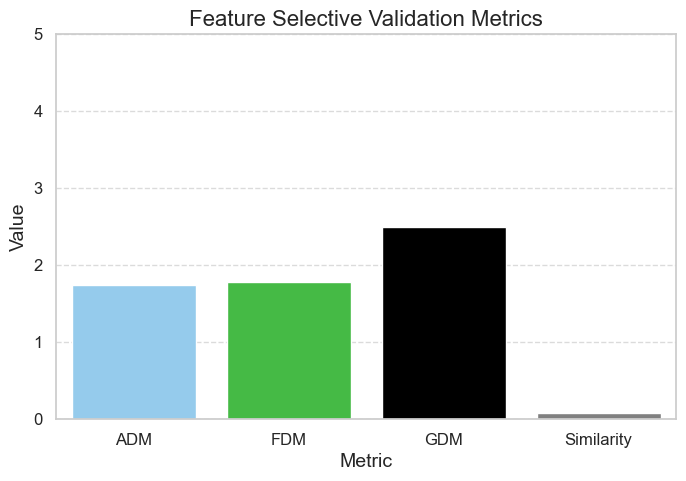

ADM: 1.743, FDM: 1.787, GDM: 2.497, Similarity: 0.083  | mode:all_vs_all, pairs:100
Amplitude Fidelity Score: 0.08


In [18]:
# Initialize class
asim = AmplitudeFidelity(fs=512)
# Compute amplitude similarity metrics
amplitude_dataset = asim.compute_amplitude_metrics(real_data, synthetic_data)
#amplitude_sample = asim.compute_metrics(real_data[0], synthetic_data[0])

# Plot amplitude similarity metrics
dataset_plot = asim.plot_amplitude_metrics(amplitude_dataset)
#sample_plot = asim.plot_metrics(amplitude_sample)

# Compute amplitude similarity score
dataset_score = evaluation_score.compute_amplitude_fidelity_score(real_data, synthetic_data, fs=512)
#sample_score = evaluation_score.compute_amplitude_fidelity_score(real_data[0], synthetic_data[0], fs=512)

#### B2. Time fidelity

=== Mean Hjorth Parameters ===
Real Signals: Activity=0.0513, Mobility=0.1095, Complexity=3.5015
Synthetic Signals: Activity=0.0560, Mobility=0.3064, Complexity=5.4564
=== Hjorth Parameters Summary ===
Activity - Wasserstein Distance: 0.0170
Mobility - Wasserstein Distance: 0.1969
Complexity - Wasserstein Distance: 1.9549
Average Wasserstein Distance: 0.7229
Mahalanobis Distance: 1.8977



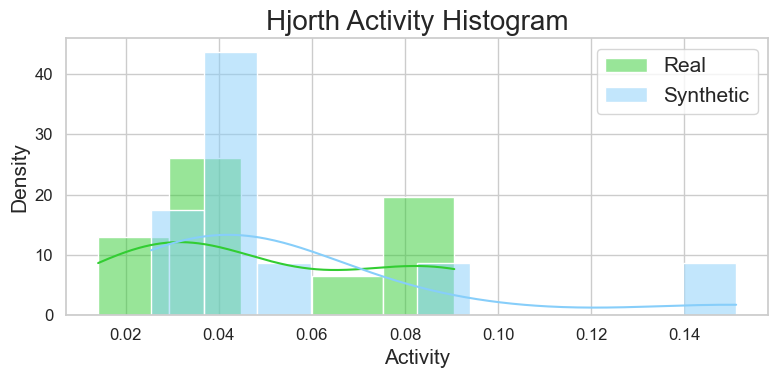

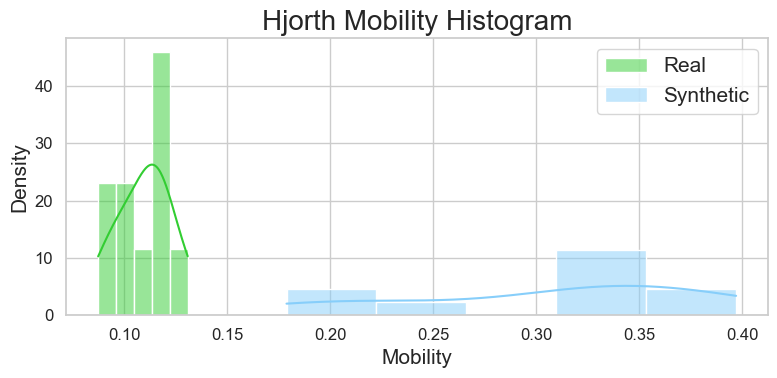

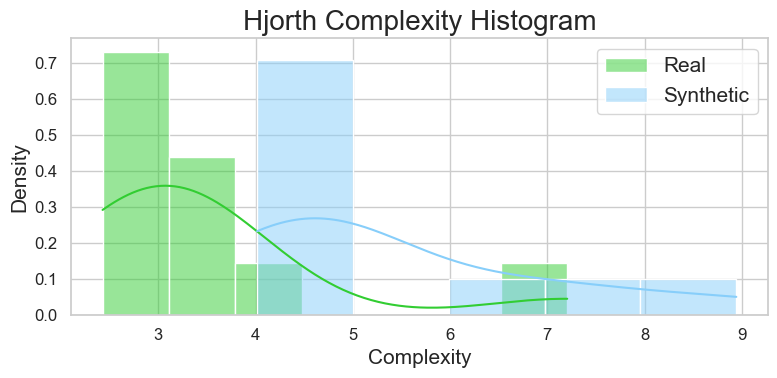

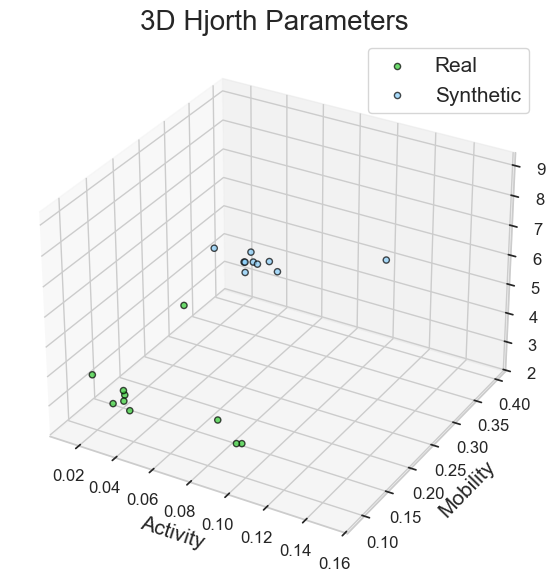

Time Fidelity Score  : 0.626
Time Fidelity Components:
  Activity: 0.983
  Mobility: 0.836
  Complexity: 0.338
  Mahalanobis: 0.345


0.6255804621878733

In [19]:
# Initialize class
sim = TimeFidelity()
# Compute hjorth metrics
hjorth_dataset = sim.compute_hjorth_metrics(real_data, synthetic_data, verbose=True)

# Plot Hjorth parameter distributions
hjorth_hist_dataset = sim.plot_hjorth_histograms(real_data, synthetic_data)

# Plot 3D Hjorth parameter scatter
hjorth_3d_dataset = sim.plot_hjorth_3d(real_data, synthetic_data)

# Compute time fidelity score
evaluation_score.compute_time_fidelity_score(real_data, synthetic_data)

#### B3. Frequency fidelity

Relative Bands Power (Dataset):
  Delta: Real: 32.55%, Synthetic: 43.19%, Diff: 10.64%
  Theta: Real: 5.06%, Synthetic: 9.40%, Diff: 4.34%
  Alpha: Real: 26.46%, Synthetic: 11.72%, Diff: 14.74%
  Beta: Real: 16.60%, Synthetic: 14.25%, Diff: 2.35%
  Gamma: Real: 0.40%, Synthetic: 4.87%, Diff: 4.47%
  Ripple: Real: 0.02%, Synthetic: 4.03%, Diff: 4.01%
  Fast Ripple: Real: 0.00%, Synthetic: 0.18%, Diff: 0.18%
Statistical Test Results (Dataset):
  Delta: Test=Paired t-test, Stat=-2.083, p-value=0.067, Cohen's d=-0.659
  Theta: Test=Paired t-test, Stat=-2.984, p-value=0.015, Cohen's d=-0.944
  Alpha: Test=Paired t-test, Stat=6.564, p-value=< 0.001 (exact=1.04e-04), Cohen's d=2.076
  Beta: Test=Paired t-test, Stat=0.913, p-value=0.385, Cohen's d=0.289
  Gamma: Test=Paired t-test, Stat=-6.341, p-value=< 0.001 (exact=1.34e-04), Cohen's d=-2.005
  Ripple: Test=Paired t-test, Stat=-7.759, p-value=< 0.001 (exact=2.82e-05), Cohen's d=-2.454
  Fast Ripple: Test=Paired t-test, Stat=-4.589, p-value=0

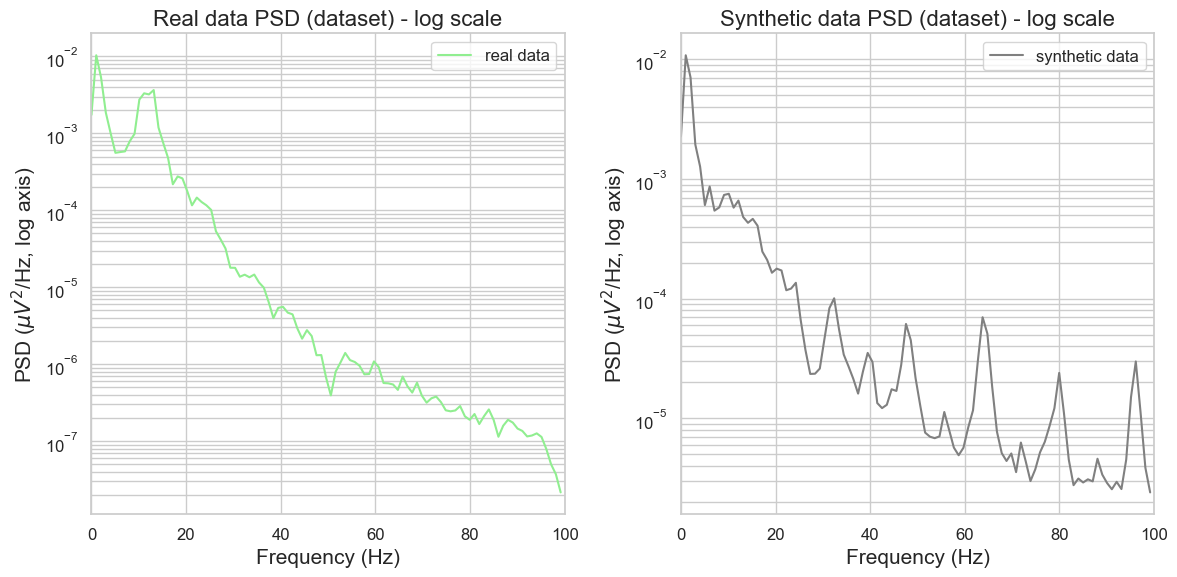

Mode: all_vs_all | RS spectral coherence=0.341 (± 0.023) (dataset)
RR  | Spectral coherence = 0.425 ± 0.083
SS  | Spectral coherence = 0.411 ± 0.039
RS  | Spectral coherence = 0.341 ± 0.023
Spectral Wasserstein distance (Hz) [0.5-100.0]: 4.3769
Frequency Fidelity Score: 0.56


0.5553019948307293

In [20]:
# Initialize class
frequency_analysis = FrequencyFidelity(fs=512)
# Compute frequency similarity metrics
# At dataset level
frequency_analysis.compare_relative_power(real_data, synthetic_data)
frequency_analysis.spectral_coherence(real_data, synthetic_data)
# At sample level
#frequency_analysis.compare_relative_power(real_data[0], synthetic_data[0])
#frequency_analysis.spectral_coherence(real_data[0], synthetic_data[0])

#Plot average PSD
# At dataset level
frequency_analysis.plot_psd(real_data, synthetic_data, scale="log")
# At sample level
#frequency_analysis.plot_psd(real_data[5], synthetic_data[5], scale="log")

# Compute frequency fidelity score
# At dataset level
evaluation_score.compute_frequency_fidelity_score(real_data, synthetic_data, fs=512)
# At sample level
#evaluation_score.compute_frequency_fidelity_score(real_data[0], synthetic_data[0], fs=512)

#### B4. Time-frequency fidelity

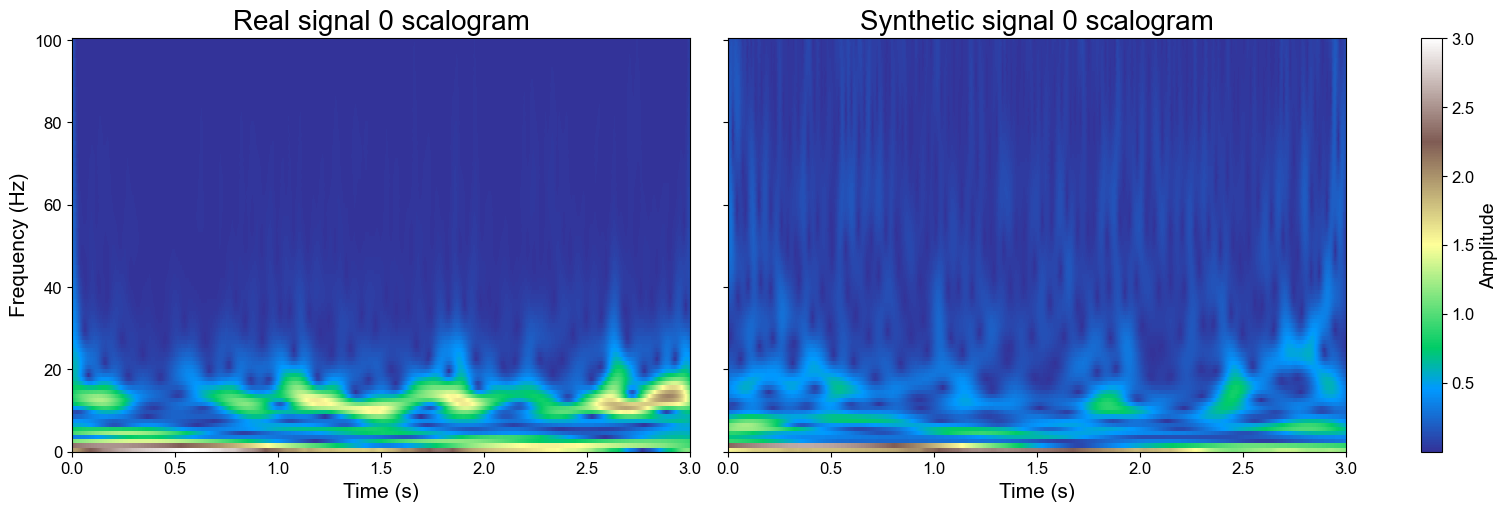

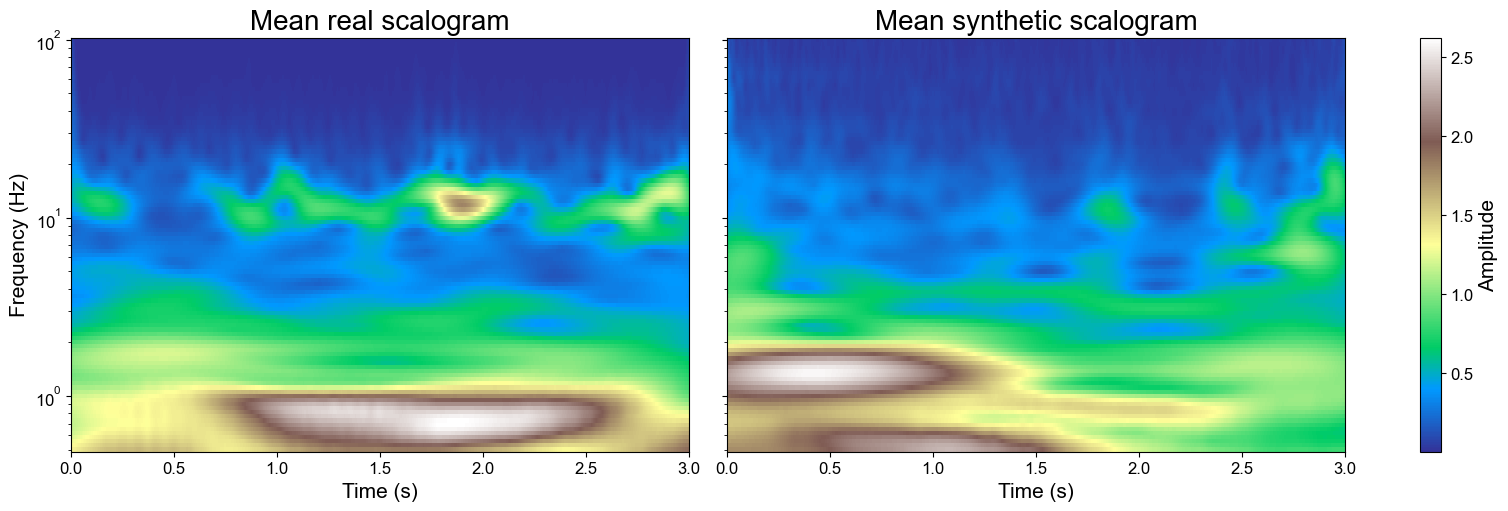

RR  | SSIM = 0.819 ± 0.0411 | NRMSE = 0.0719 ± 0.0188 | Cosine = 0.833 ± 0.0618 | mode: all_vs_all, pairs: 45 (dataset)
RS  | SSIM = 0.726 ± 0.0491 | NRMSE = 0.0814 ± 0.0132 | Cosine = 0.726 ± 0.0716 | mode: all_vs_all, pairs: 100 (dataset)
SS  | SSIM = 0.721 ± 0.0774 | NRMSE = 0.0631 ± 0.0124 | Cosine = 0.834 ± 0.0553 | mode: all_vs_all, pairs: 45 (dataset)

=== Burst Statistics Summary ===
Band: 13–30 Hz | Threshold: percentile (p=75) | min_dur=100.0 ms | merge_gap=50.0 ms | smooth=50.0 ms
N_real=10 | N_synth=10

Feature                  RS WD     RR disp     SS disp
------------------------------------------------------
n_bursts                   0.4        0.36         0.7
rate_hz                  0.133        0.12       0.233
mean_dur_s              0.0352      0.0572       0.045
median_dur_s            0.0285      0.0723      0.0574
mean_peak               0.0685       0.141      0.0779
median_peak             0.0673       0.152      0.0758
mean_IBI_s               0.777       0.

0.7857694822795085

In [32]:
# Initialize class
time_frequency_analysis = TimeFrequencyFidelity(fs=512)

# Plot scalograms
# At sample level
time_frequency_analysis.plot_scalograms(real_data, synthetic_data, signal_index_real=0, signal_index_synth=0)
# At dataset level
time_frequency_analysis.plot_mean_scalograms(real_data,synthetic_data, freq_scale="log")

# Compute time-frequency similarity metrics
# At dataset level
time_frequency_analysis.compute_scalogram_similarity_metrics(real_data,synthetic_data)
# At sample level
#time_frequency_analysis.compute_scalogram_similarity_metrics(real_data[0], synthetic_data[0])

# Compute burst statistics within the beta band
burst_results = time_frequency_analysis.compute_burst_statistics(real_data, synthetic_data, band=(13, 30))

# Compute time-frequency fidelity score
#evaluation_score.compute_time_frequency_fidelity_score(real_data[1], synthetic_data[3], fs=512)
evaluation_score.compute_time_frequency_fidelity_score(real_data, synthetic_data, fs=512, mode="all_vs_all")

#### B5. Complexity fidelity


MFDCCA Cross-Hurst Exponent (avg H(q)):
  real vs real:        1.3830 ± 0.0614
  real vs synthetic:   1.3270 ± 0.0563
  synthetic vs synthetic: 1.2676 ± 0.0492

MFDCCA Cross-Fluctuation F_xy(q) [averaged]:
  real vs real:        0.4101 ± 0.0828
  real vs synthetic:   0.3616 ± 0.0594
  synthetic vs synthetic: 0.3412 ± 0.0275

MFDCCA Width of Singularity Spectrum (Δα):
  real vs real:        1.0109 ± 0.1787
  real vs synthetic:   0.7238 ± 0.1802
  synthetic vs synthetic: 0.3905 ± 0.1595

MFDCCA Cross-Correlation Ratio p(q) [averaged over q]:
  real vs real:        0.9979 ± 0.0311
  real vs synthetic:   0.9444 ± 0.0251
  synthetic vs synthetic: 0.8969 ± 0.0185

MFDCCA Hurst Exponent:
  real vs real: Mean = 1.3830, Std = 0.0614
  real vs synthetic: Mean = 1.3270, Std = 0.0563
  synthetic vs synthetic: Mean = 1.2676, Std = 0.0492


TypeError: ComplexityFidelity.plot_metrics() got an unexpected keyword argument 'axs'

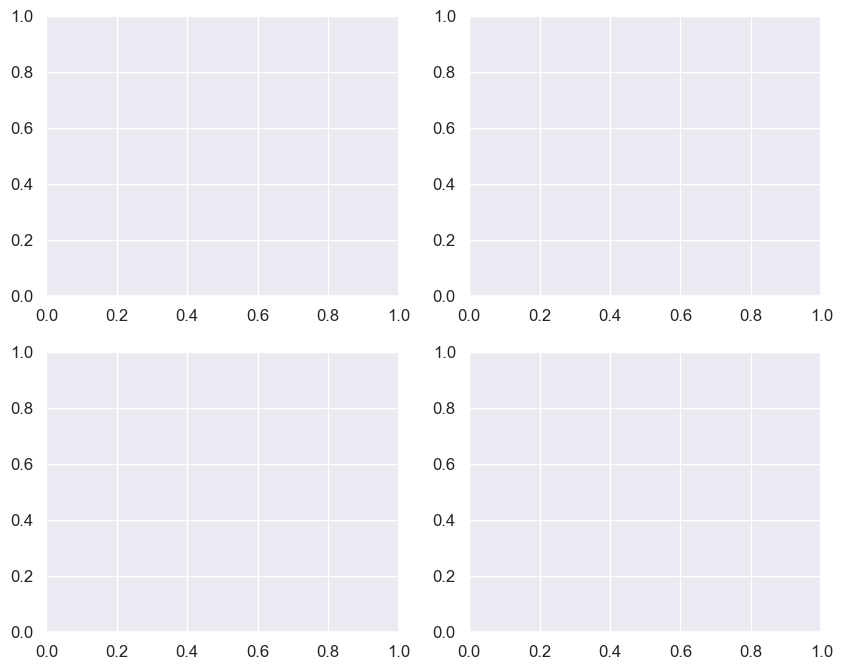

In [12]:
# Initialize class for MFDCCA method (for DCCA and MFDFA, specify method accordingly)
cf = ComplexityFidelity(real_data, synthetic_data, method='MFDCCA')

# Compute MFDCCA metrics
cf.compute_fractal_metrics()
# Plot MFDCCA metrics
#cf.plot_metrics()

# python
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
cf.plot_metrics(axs=axs)
plt.show()


# Compute entropy metrics
entropy_metrics = cf.compute_entropy_complexity_metrics(real_data, synthetic_data)

# Compute complexity fidelity score
evaluation_score.compute_complexity_fidelity_score(real_data, synthetic_data)

#### C. Diversity evaluation




[Manifold Coverage] Sigma: 10.4905
[Manifold Coverage] Coverage (real→synth): 0.561  (↑ better)
[Manifold Coverage] Outlier Goodness (synth→real): 0.581  (↑ better)
[Geometric Diversity] PCA  -> Compactness: 0.716 | Mahalanobis Overlap: 0.009
[Geometric Diversity] UMAP -> Compactness: 0.739 | Mahalanobis Overlap: 0.013
[Intrinsic Diversity] Uniqueness (NN ratio, syn/real): 1.315  (~1 ideal; <1 collapse; >1 over-dispersion)
[Intrinsic Diversity] Global Diversity (pairwise ratio, syn/real): 1.278
[Intrinsic Diversity] Local Diversity P10 / P50 (NN ratio): 1.775 / 1.447


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


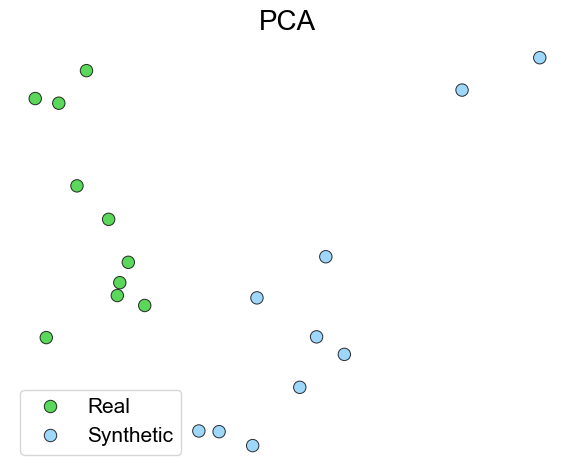

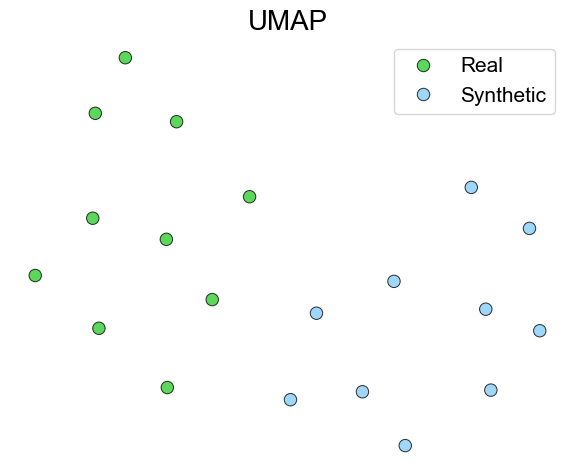

[Manifold Coverage] Sigma: 10.4905
[Manifold Coverage] Coverage (real→synth): 0.561  (↑ better)
[Manifold Coverage] Outlier Goodness (synth→real): 0.581  (↑ better)
[Geometric Diversity] PCA  -> Compactness: 0.716 | Mahalanobis Overlap: 0.009
[Geometric Diversity] UMAP -> Compactness: 0.739 | Mahalanobis Overlap: 0.013
[Intrinsic Diversity] Uniqueness (NN ratio, syn/real): 1.315  (~1 ideal; <1 collapse; >1 over-dispersion)
[Intrinsic Diversity] Global Diversity (pairwise ratio, syn/real): 1.278
[Intrinsic Diversity] Local Diversity P10 / P50 (NN ratio): 1.775 / 1.447
Diversity Score: 0.539
Coverage: 0.561
Outlier Goodness: 0.581
PCA Compactness: 0.716
UMAP Compactness: 0.739
PCA Overlap: 0.009
UMAP Overlap: 0.013
Uniqueness: 0.760
Local Diversity: 0.691
Global Diversity: 0.783


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


0.5392640435947529

In [34]:
# Initialize class
div = Diversity()

# Compute coverage diversity metrics
cov = div.compute_coverage_diversity(real_data, synthetic_data)

# Compute geometric diversity metrics
geom = div.compute_geometric_diversity(real_data, synthetic_data)

# Compute intrinsic diversity metrics
intr = div.compute_intrinsic_diversity(real_data, synthetic_data)

# Plot PCA and UMAP results
div.plot_embeddings("PCA", geom)
#div.plot_embeddings("UMAP", geom)

# Compute diversity score
evaluation_score.compute_diversity_score(real_data, synthetic_data)

#### D. Privacy evaluation

In [35]:
# Initialize class
privacy_analysis = Privacy()

# Compute distance and MIR metrics
distance_metrics = privacy_analysis.compute_distance_metrics(real_data, synthetic_data)
mir = privacy_analysis.compute_mir(real_data, synthetic_data)

# Compute privacy score
evaluation_score.compute_privacy_score(real_data, synthetic_data)

📏 Distance Metrics Between Real and Synthetic Data:
  - Wasserstein Distance (WD): 0.0316 (min: 0.0088)
  - Euclidean Distance   (ED): 0.0534 (min: 0.0338)
  - Jensen–Shannon Divergence (JSD): 0.1460 (min: 0.0758)

🔐 Membership Inference Risk (MIR) Metrics:
🕵️ Attack via correctness: acc = 0.700
🕵️ Attack via confidence: acc = 0.900
🕵️ Attack via entropy: acc = 0.900
🕵️ Attack via modified entropy: acc = 0.900
  - Correctness Attack Acc: 0.7
  - Confidence Attack Acc: 0.9
  - Entropy Attack Acc: 0.9
  - Modified Entropy Attack Acc: 0.9
  - Synthetic Member Fraction: 0.0

🕵️ Attack via correctness: acc = 0.800
🕵️ Attack via confidence: acc = 1.000
🕵️ Attack via entropy: acc = 1.000
🕵️ Attack via modified entropy: acc = 1.000
Privacy Score: 0.06
  - WD Score:  0.03
  - ED Score:  0.05
  - JSD Score: 0.15
  - MIR Score: 0.00


0.05684168981620778